# Notebook 1 — Analyse Exploratoire des Données (EDA)
**Health & Lifestyle Dataset** — 100 000 individus, 15 variables


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../health_lifestyle_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 16)


,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


## 1. Informations générales

In [2]:
print('=== TYPES ===')
print(df.dtypes)
print('\n=== VALEURS MANQUANTES ===')
print(df.isnull().sum())

=== TYPES ===
id                     int64
age                    int64
gender                object
bmi                  float64
daily_steps            int64
sleep_hours          float64
water_intake_l       float64
calories_consumed      int64
smoker                 int64
alcohol                int64
resting_hr             int64
systolic_bp            int64
diastolic_bp           int64
cholesterol            int64
family_history         int64
disease_risk           int64
dtype: object

=== VALEURS MANQUANTES ===
id                   0
age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64


## 2. Statistiques descriptives

In [3]:
df.describe().round(2)

,id,age,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,48.53,29.02,10479.87,6.49,2.75,2603.34,0.2,0.30,74.46,134.58,89.51,224.30,0.30,0.25
std,28867.66,17.89,6.35,5483.63,2.02,1.30,807.29,0.4,0.46,14.42,25.95,17.35,43.33,0.46,0.43
min,1.00,18.00,18.00,1000.00,3.00,0.50,1200.00,0.0,0.00,50.00,90.00,60.00,150.00,0.00,0.00
25%,25000.75,33.00,23.50,5729.00,4.70,1.60,1906.00,0.0,0.00,62.00,112.00,74.00,187.00,0.00,0.00
50%,50000.50,48.00,29.00,10468.00,6.50,2.80,2603.00,0.0,0.00,74.00,135.00,89.00,224.00,0.00,0.00
75%,75000.25,64.00,34.50,15229.00,8.20,3.90,3299.00,0.0,1.00,87.00,157.00,105.00,262.00,1.00,0.00
max,100000.00,79.00,40.00,19999.00,10.00,5.00,3999.00,1.0,1.00,99.00,179.00,119.00,299.00,1.00,1.00


## 3. Distribution de la variable cible

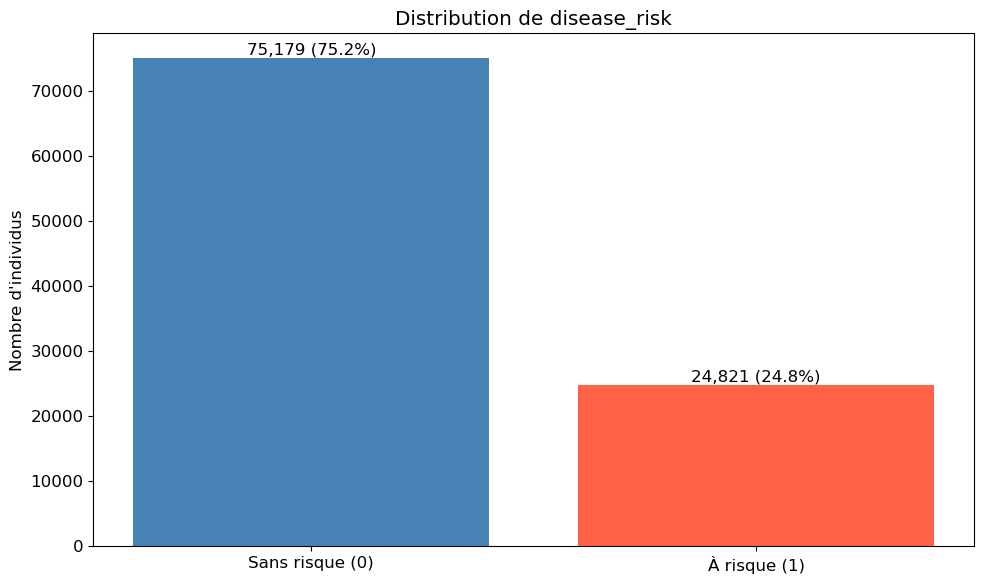

In [4]:
fig, ax = plt.subplots()
counts = df['disease_risk'].value_counts()
ax.bar(['Sans risque (0)', 'À risque (1)'], counts.values, color=['steelblue','tomato'])
ax.set_title('Distribution de disease_risk')
ax.set_ylabel('Nombre d\'individus')
for i, v in enumerate(counts.values):
    ax.text(i, v+500, f'{v:,} ({v/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('../figures/disease_risk_distribution.png', dpi=150)
plt.show()

## 4. Distributions des variables continues

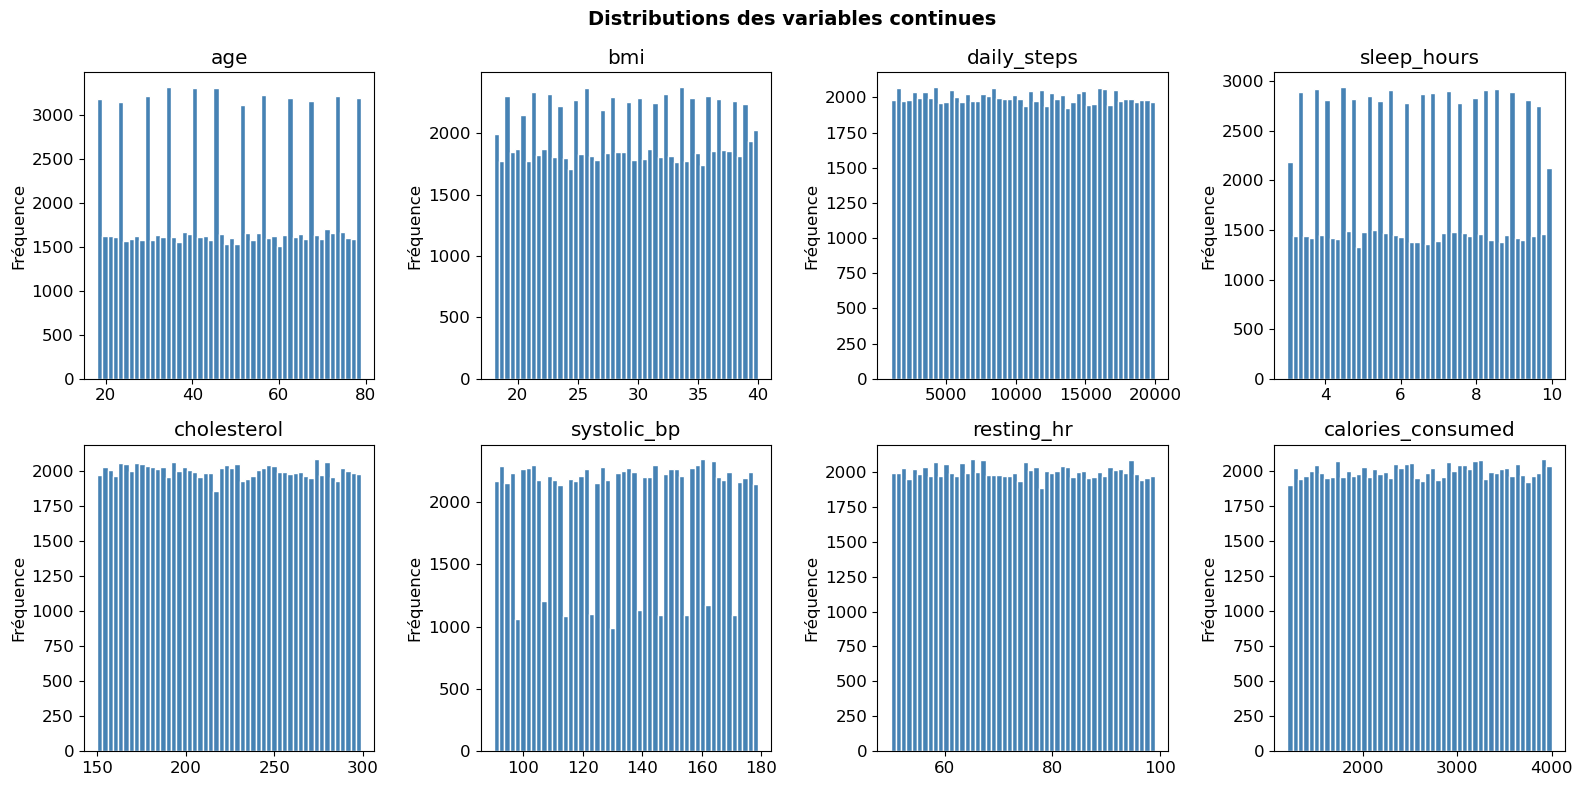

In [5]:
continuous = ['age','bmi','daily_steps','sleep_hours','cholesterol','systolic_bp','resting_hr','calories_consumed']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), continuous):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Fréquence')
plt.suptitle('Distributions des variables continues', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/distributions_continues.png', dpi=150)
plt.show()

## 5. Matrice de corrélation

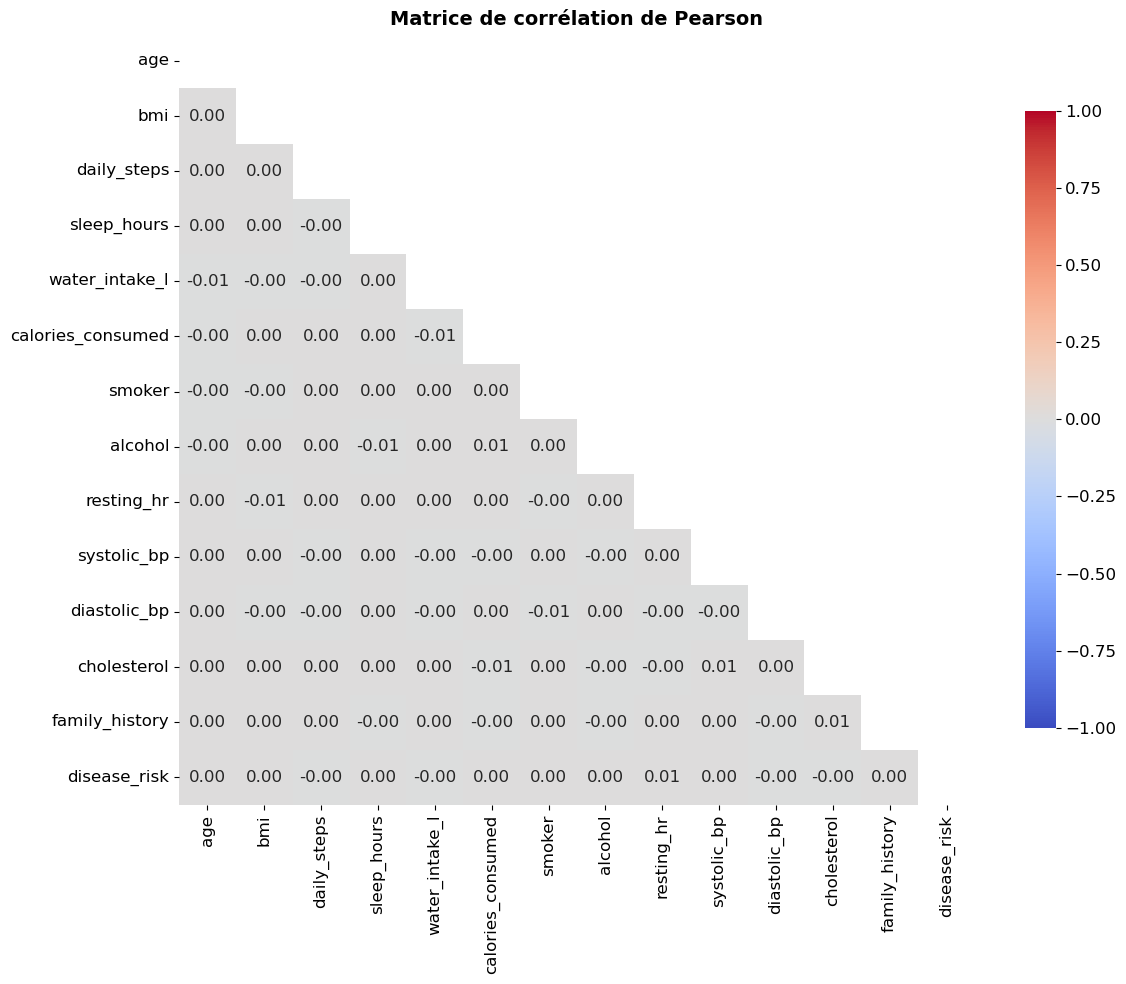

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.select_dtypes(include='number').drop('id', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Matrice de corrélation de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', dpi=150)
plt.show()

## 6. Corrélations avec disease_risk

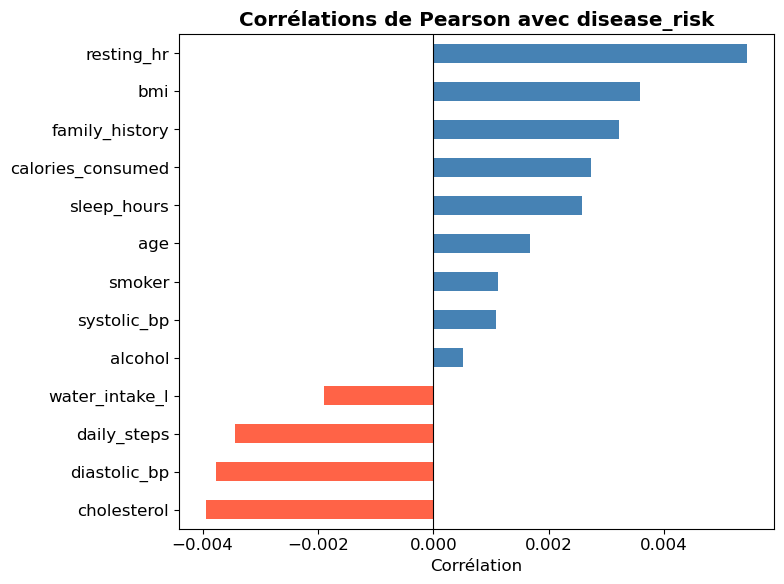

In [7]:
corr_target = df.select_dtypes(include='number').corr()['disease_risk'].drop(['disease_risk','id']).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
corr_target.plot(kind='barh', ax=ax, color=['tomato' if x < 0 else 'steelblue' for x in corr_target])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélations de Pearson avec disease_risk', fontweight='bold')
ax.set_xlabel('Corrélation')
plt.tight_layout()
plt.savefig('../figures/correlations_target.png', dpi=150)
plt.show()

In [8]:
# Valeurs exactes utilisées dans le mémoire (section "Résultat central")
corr_target = df.select_dtypes(include='number').corr()['disease_risk'].drop(['disease_risk','id'])
max_corr_var = corr_target.abs().idxmax()
max_corr_val = corr_target[max_corr_var]

print("=== JUSTIFICATION DES VALEURS CITÉES DANS LE MÉMOIRE ===")
print(f"\nCorr. max avec disease_risk : {max_corr_var} → r = {max_corr_val:.4f}")
print(f"Toutes corrélations < |0.01| : {(corr_target.abs() < 0.01).all()}")
print(f"\nSkewness de toutes les variables continues :")
continuous = ['age','bmi','daily_steps','sleep_hours','cholesterol','systolic_bp','resting_hr','calories_consumed']
skew = df[continuous].skew()
print(skew.round(4))
print(f"\nSkewness max (valeur absolue) : {skew.abs().max():.4f} → quasi-uniforme")

=== JUSTIFICATION DES VALEURS CITÉES DANS LE MÉMOIRE ===

Corr. max avec disease_risk : resting_hr → r = 0.0054
Toutes corrélations < |0.01| : True

Skewness de toutes les variables continues :
age                  0.0013
bmi                 -0.0035
daily_steps          0.0034
sleep_hours          0.0017
cholesterol          0.0062
systolic_bp         -0.0108
resting_hr           0.0044
calories_consumed   -0.0045
dtype: float64

Skewness max (valeur absolue) : 0.0108 → quasi-uniforme


## 7. Comparaison des moyennes par groupe disease_risk

In [9]:
cols = ['age','bmi','daily_steps','sleep_hours','cholesterol','systolic_bp','resting_hr']
df.groupby('disease_risk')[cols].mean().round(2)

,age,bmi,daily_steps,sleep_hours,cholesterol,systolic_bp,resting_hr
disease_risk,,,,,,,
0,48.51,29.01,10490.72,6.49,224.4,134.56,74.41
1,48.58,29.06,10447.00,6.50,224.0,134.63,74.59


## 8. Corrélations de Spearman

Pearson ne détecte que les relations **linéaires**. Spearman mesure la corrélation des rangs et capture toute relation **monotone non-linéaire** (croissante ou décroissante, même courbée).

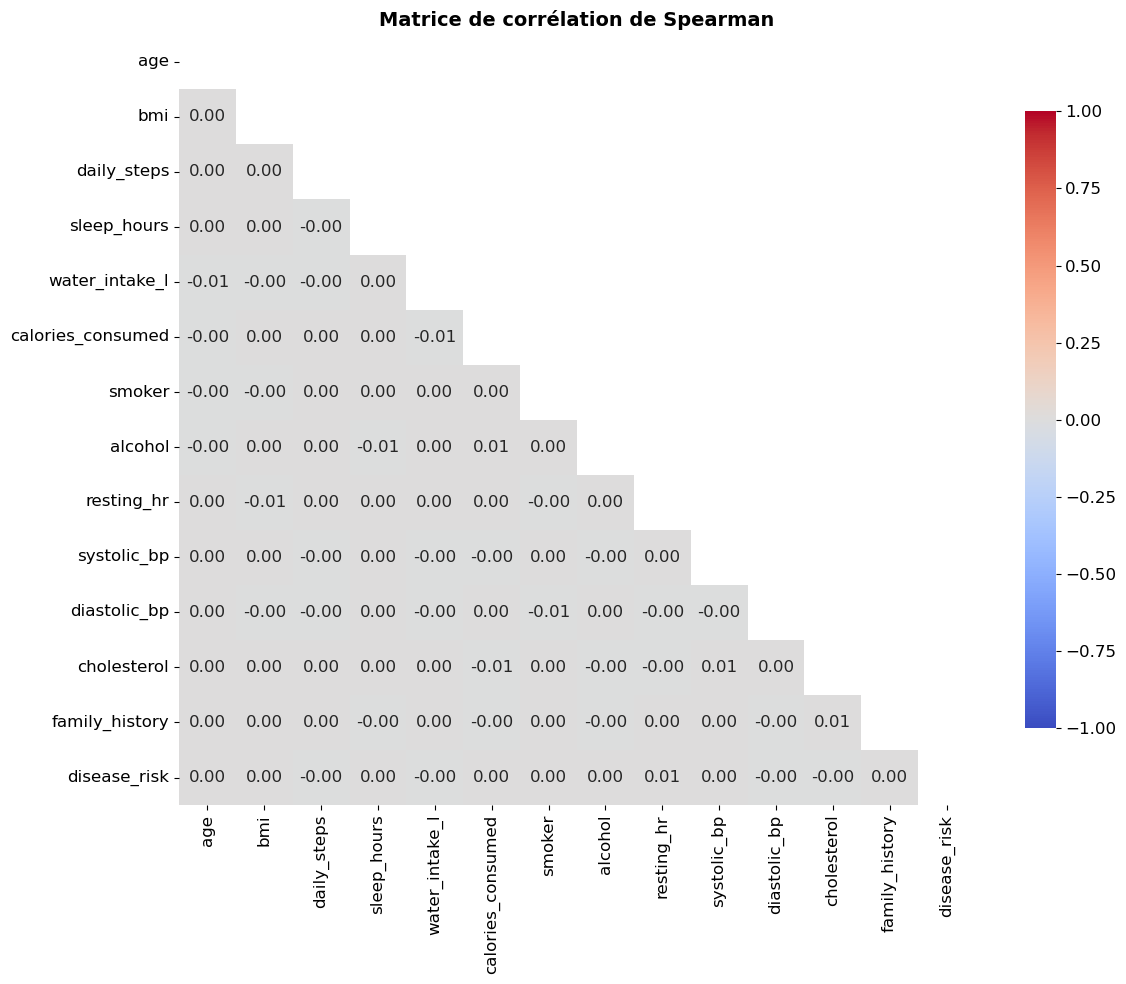

In [10]:
numeric_cols = df.select_dtypes(include='number').drop('id', axis=1)

spearman_corr = numeric_cols.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation de Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/spearman_matrix.png', dpi=150)
plt.show()

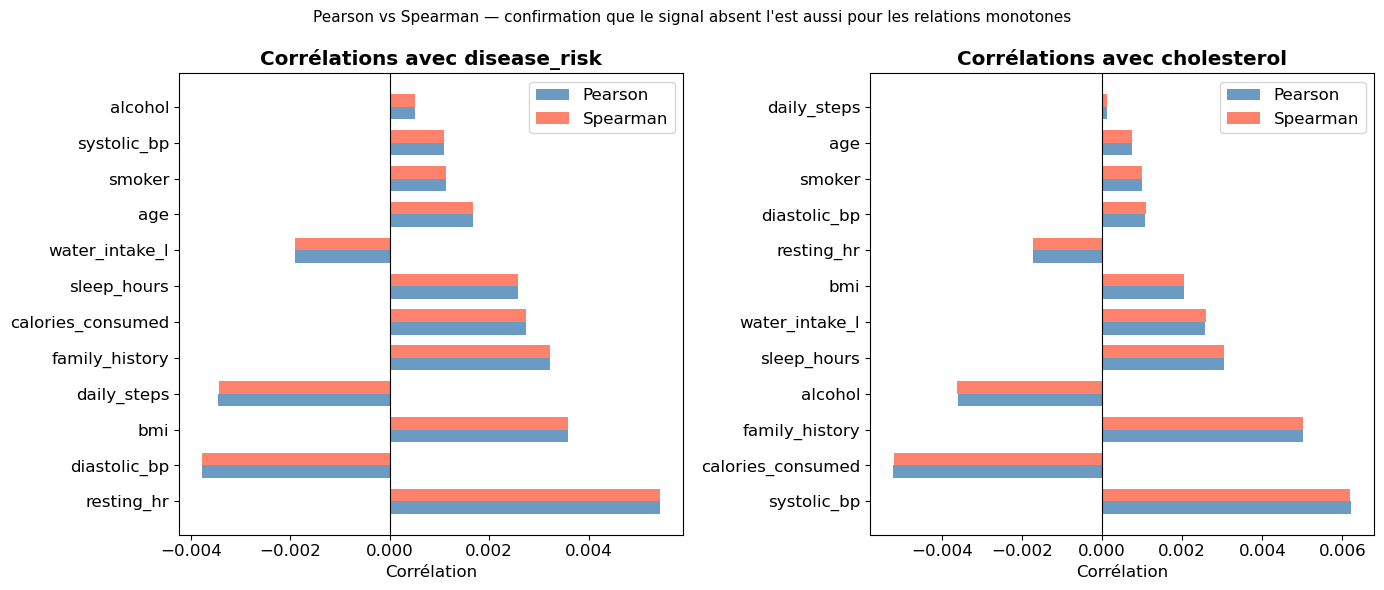

=== PEARSON vs SPEARMAN — disease_risk ===
                   Pearson  Spearman
resting_hr          0.0054    0.0054
diastolic_bp       -0.0038   -0.0038
bmi                 0.0036    0.0036
daily_steps        -0.0034   -0.0034
family_history      0.0032    0.0032
calories_consumed   0.0027    0.0027
sleep_hours         0.0026    0.0026
water_intake_l     -0.0019   -0.0019
age                 0.0017    0.0017
smoker              0.0011    0.0011
systolic_bp         0.0011    0.0011
alcohol             0.0005    0.0005

Max |Spearman| : 0.0054

=== PEARSON vs SPEARMAN — cholesterol ===
                   Pearson  Spearman
systolic_bp         0.0062    0.0062
calories_consumed  -0.0052   -0.0052
family_history      0.0050    0.0050
alcohol            -0.0036   -0.0036
sleep_hours         0.0031    0.0030
water_intake_l      0.0026    0.0026
bmi                 0.0020    0.0021
resting_hr         -0.0017   -0.0017
diastolic_bp        0.0011    0.0011
smoker              0.0010    0.0010
a

In [11]:
# Comparaison Pearson vs Spearman sur les deux cibles
pearson_risk    = numeric_cols.corr()['disease_risk'].drop('disease_risk')
spearman_risk   = numeric_cols.corr(method='spearman')['disease_risk'].drop('disease_risk')
pearson_chol    = numeric_cols.corr()['cholesterol'].drop('cholesterol')
spearman_chol   = numeric_cols.corr(method='spearman')['cholesterol'].drop('cholesterol')

comparison_risk = pd.DataFrame({
    'Pearson':  pearson_risk.drop('cholesterol', errors='ignore'),
    'Spearman': spearman_risk.drop('cholesterol', errors='ignore')
}).sort_values('Spearman', key=abs, ascending=False)

comparison_chol = pd.DataFrame({
    'Pearson':  pearson_chol.drop('disease_risk', errors='ignore'),
    'Spearman': spearman_chol.drop('disease_risk', errors='ignore')
}).sort_values('Spearman', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_cmp, title in zip(axes,
    [comparison_risk, comparison_chol],
    ['Corrélations avec disease_risk', 'Corrélations avec cholesterol']):
    x = range(len(df_cmp))
    width = 0.35
    ax.barh([i - width/2 for i in x], df_cmp['Pearson'],  width, label='Pearson',  color='steelblue', alpha=0.8)
    ax.barh([i + width/2 for i in x], df_cmp['Spearman'], width, label='Spearman', color='tomato',    alpha=0.8)
    ax.set_yticks(list(x))
    ax.set_yticklabels(df_cmp.index)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Corrélation')
    ax.legend()

plt.suptitle('Pearson vs Spearman — confirmation que le signal absent l\'est aussi pour les relations monotones',
             fontsize=11)
plt.tight_layout()
plt.savefig('../figures/pearson_vs_spearman.png', dpi=150)
plt.show()

print("=== PEARSON vs SPEARMAN — disease_risk ===")
print(comparison_risk.round(4))
print(f"\nMax |Spearman| : {spearman_risk.drop('cholesterol', errors='ignore').abs().max():.4f}")
print("\n=== PEARSON vs SPEARMAN — cholesterol ===")
print(comparison_chol.round(4))
print(f"\nMax |Spearman| : {spearman_chol.drop('disease_risk', errors='ignore').abs().max():.4f}")
print("\n→ Spearman confirme Pearson : aucune relation monotone non-linéaire détectable")

## 9. Information Mutuelle (Mutual Information)

La Mutual Information mesure **toute dépendance statistique** entre deux variables, quelle que soit sa forme (linéaire, non-linéaire, non-monotone). C'est la mesure la plus générale possible de dépendance.

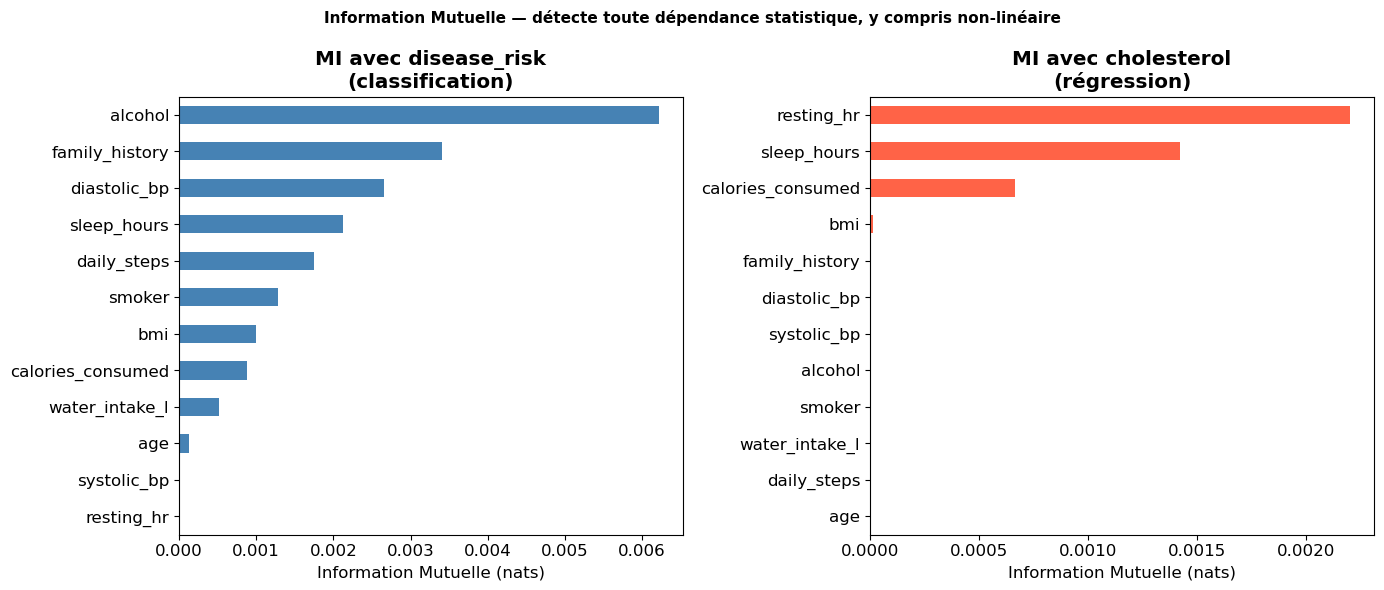

=== MUTUAL INFORMATION — disease_risk ===
alcohol              0.00622
family_history       0.00341
diastolic_bp         0.00266
sleep_hours          0.00212
daily_steps          0.00175
smoker               0.00128
bmi                  0.00100
calories_consumed    0.00089
water_intake_l       0.00052
age                  0.00013
resting_hr           0.00000
systolic_bp          0.00000
dtype: float64

Max MI (disease_risk) : 0.00622

=== MUTUAL INFORMATION — cholesterol ===
resting_hr           0.00220
sleep_hours          0.00142
calories_consumed    0.00066
bmi                  0.00001
age                  0.00000
daily_steps          0.00000
water_intake_l       0.00000
smoker               0.00000
alcohol              0.00000
systolic_bp          0.00000
diastolic_bp         0.00000
family_history       0.00000
dtype: float64

Max MI (cholesterol)  : 0.00220

→ MI ≈ 0 pour toutes les features : aucune dépendance statistique détectable,
  même non-linéaire → confirme RF/XGBoost et 

In [12]:
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

features = numeric_cols.drop(['disease_risk', 'cholesterol'], axis=1)

mi_risk  = mutual_info_classif(features, df['disease_risk'], random_state=42)
mi_chol  = mutual_info_regression(features, df['cholesterol'], random_state=42)

mi_risk_s = pd.Series(mi_risk, index=features.columns).sort_values(ascending=False)
mi_chol_s = pd.Series(mi_chol, index=features.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mi_risk_s.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('MI avec disease_risk\n(classification)', fontweight='bold')
axes[0].set_xlabel('Information Mutuelle (nats)')

mi_chol_s.sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('MI avec cholesterol\n(régression)', fontweight='bold')
axes[1].set_xlabel('Information Mutuelle (nats)')

plt.suptitle('Information Mutuelle — détecte toute dépendance statistique, y compris non-linéaire',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/mutual_information.png', dpi=150)
plt.show()

print("=== MUTUAL INFORMATION — disease_risk ===")
print(mi_risk_s.round(5))
print(f"\nMax MI (disease_risk) : {mi_risk_s.max():.5f}")
print("\n=== MUTUAL INFORMATION — cholesterol ===")
print(mi_chol_s.round(5))
print(f"\nMax MI (cholesterol)  : {mi_chol_s.max():.5f}")
print("\n→ MI ≈ 0 pour toutes les features : aucune dépendance statistique détectable,")
print("  même non-linéaire → confirme RF/XGBoost et Spearman")

## 10. Nuages de points (Scatter plots)

Visualisation directe des relations entre variables explicatives et cibles. Si une relation existait, les points formeraient une tendance visible.

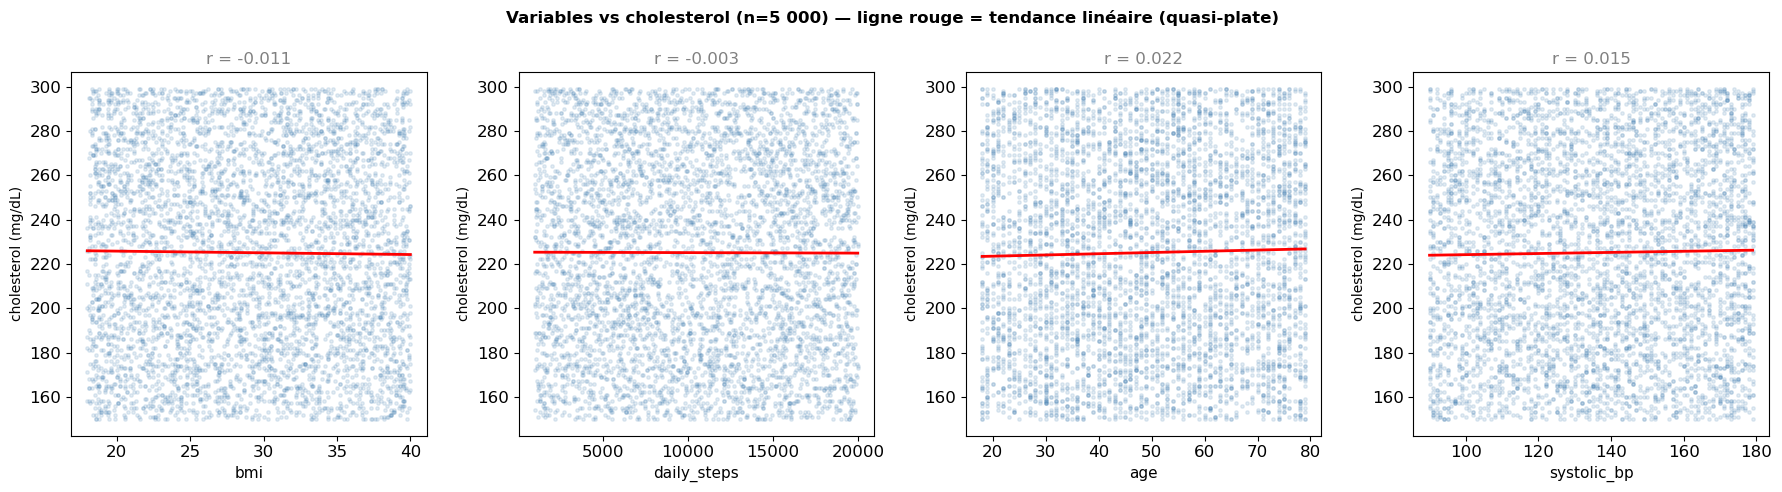

In [13]:
# Sous-échantillon pour la lisibilité
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=5000, replace=False)
df_s = df.iloc[idx]

vars_chol = ['bmi', 'daily_steps', 'age', 'systolic_bp']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, var in zip(axes, vars_chol):
    ax.scatter(df_s[var], df_s['cholesterol'], alpha=0.15, s=6, color='steelblue')
    z = np.polyfit(df_s[var], df_s['cholesterol'], 1)
    x_line = np.linspace(df_s[var].min(), df_s[var].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2)
    r = df_s[[var, 'cholesterol']].corr().iloc[0, 1]
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel('cholesterol (mg/dL)', fontsize=10)
    ax.set_title(f'r = {r:.3f}', fontsize=12, color='darkred' if abs(r) > 0.1 else 'gray')

plt.suptitle('Variables vs cholesterol (n=5 000) — ligne rouge = tendance linéaire (quasi-plate)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/scatter_vs_cholesterol.png', dpi=150)
plt.show()

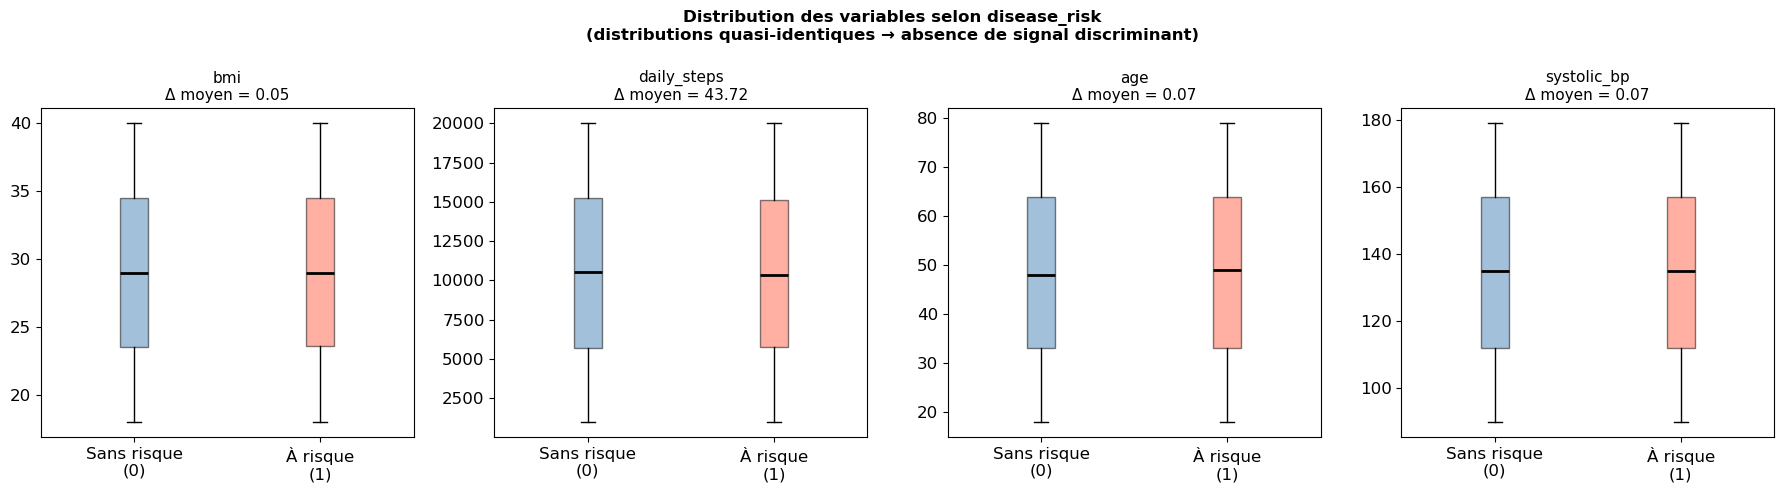

In [14]:
# Boxplots par classe disease_risk
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
vars_risk = ['bmi', 'daily_steps', 'age', 'systolic_bp']

for ax, var in zip(axes, vars_risk):
    data_0 = df[df['disease_risk'] == 0][var]
    data_1 = df[df['disease_risk'] == 1][var]
    bp = ax.boxplot([data_0, data_1],
                    labels=['Sans risque\n(0)', 'À risque\n(1)'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('tomato')
    bp['boxes'][1].set_alpha(0.5)
    delta = abs(data_0.mean() - data_1.mean())
    ax.set_title(f'{var}\nΔ moyen = {delta:.2f}', fontsize=11)

plt.suptitle('Distribution des variables selon disease_risk\n(distributions quasi-identiques → absence de signal discriminant)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/boxplots_by_risk.png', dpi=150)
plt.show()

## 11. Tests statistiques non-paramétriques (Mann-Whitney U)

Le test de Mann-Whitney U compare les distributions de deux groupes **sans hypothèse de normalité** et sans être limité aux effets linéaires. Il teste si les individus du groupe 1 ont tendance à avoir des valeurs plus élevées que ceux du groupe 0.

In [15]:
from scipy import stats

print("=== TEST DE MANN-WHITNEY U — disease_risk (0 vs 1) ===")
print(f"{'Variable':<20} {'stat U':>12} {'p-value':>12} {'Significatif (α=0.05)':>22}")
print("-" * 70)

for var in ['bmi','daily_steps','age','sleep_hours','cholesterol',
            'systolic_bp','resting_hr','calories_consumed','water_intake_l']:
    g0 = df[df['disease_risk'] == 0][var]
    g1 = df[df['disease_risk'] == 1][var]
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '✓ Oui (mais ε minime)' if p < 0.05 else '✗ Non'
    print(f"{var:<20} {stat:>12.0f} {p:>12.4f} {sig:>22}")

print()
print("Note : avec n=100 000, même des différences infinitésimales peuvent être")
print("'significatives' (p < 0.05). L'effet size (taille d'effet) est ce qui compte.")
print()
print("=== EFFET SIZE (r = Z/√n) ===")
for var in ['bmi','daily_steps','age','systolic_bp','cholesterol']:
    g0 = df[df['disease_risk'] == 0][var]
    g1 = df[df['disease_risk'] == 1][var]
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    n = len(g0) + len(g1)
    z = stats.norm.ppf(1 - p/2)
    r = z / np.sqrt(n)
    print(f"{var:<20} r = {r:.4f}  ({'négligeable' if abs(r) < 0.1 else 'petit' if abs(r) < 0.3 else 'moyen'})")

print("\n→ r < 0.1 pour toutes les variables : effet négligeable,")
print("  confirme l'absence de signal pratiquement significatif")

=== TEST DE MANN-WHITNEY U — disease_risk (0 vs 1) ===
Variable                   stat U      p-value  Significatif (α=0.05)
----------------------------------------------------------------------
bmi                     928541392       0.2572                  ✗ Non
daily_steps             937289884       0.2777                  ✗ Non
age                     930914695       0.5953                  ✗ Non
sleep_hours             929800776       0.4158                  ✗ Non
cholesterol             937930451       0.2120                  ✗ Non
systolic_bp             931653436       0.7310                  ✗ Non
resting_hr              926228230       0.0855                  ✗ Non
calories_consumed       929587402       0.3856                  ✗ Non
water_intake_l          935381272       0.5474                  ✗ Non

Note : avec n=100 000, même des différences infinitésimales peuvent être
'significatives' (p < 0.05). L'effet size (taille d'effet) est ce qui compte.

=== EFFET SIZE (r = Z